In [18]:
import numpy as np
import pandas as pd
import seaborn as sns

In [19]:
iris_data = pd.read_csv('iris.data')
iris_data

,5.1,3.5,1.4,0.2,Iris-setosa
0,4.9,3.0,1.4,0.2,Iris-setosa
1,4.7,3.2,1.3,0.2,Iris-setosa
2,4.6,3.1,1.5,0.2,Iris-setosa
3,5.0,3.6,1.4,0.2,Iris-setosa
4,5.4,3.9,1.7,0.4,Iris-setosa
...,...,...,...,...,...
144,6.7,3.0,5.2,2.3,Iris-virginica
145,6.3,2.5,5.0,1.9,Iris-virginica
146,6.5,3.0,5.2,2.0,Iris-virginica
147,6.2,3.4,5.4,2.3,Iris-virginica


In [20]:
columns_name = ['Sepal length', 'Sepal width', 'Petal length', 'Petal width', 'class']
iris_data.columns = columns_name
iris_data.head()

,Sepal length,Sepal width,Petal length,Petal width,class
0,4.9,3.0,1.4,0.2,Iris-setosa
1,4.7,3.2,1.3,0.2,Iris-setosa
2,4.6,3.1,1.5,0.2,Iris-setosa
3,5.0,3.6,1.4,0.2,Iris-setosa
4,5.4,3.9,1.7,0.4,Iris-setosa


In [21]:
iris_data.isnull().sum()

Sepal length    0
Sepal width     0
Petal length    0
Petal width     0
class           0
dtype: int64

In [22]:
iris_data.value_counts('class')

class
Iris-versicolor    50
Iris-virginica     50
Iris-setosa        49
Name: count, dtype: int64

<Axes: xlabel='class', ylabel='count'>

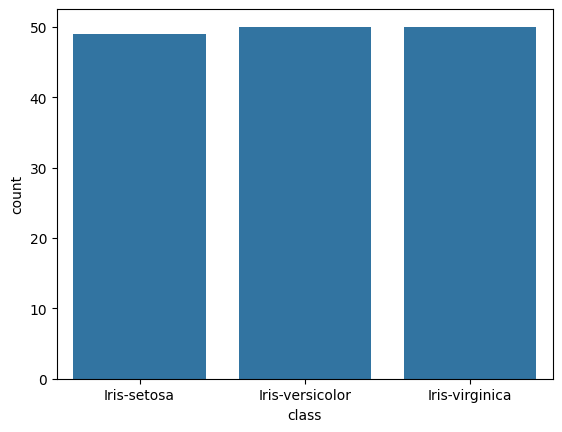

In [23]:
sns.countplot(x='class', data=iris_data)

[Text(0.5, 1.0, 'Sepal Length and Sepal Width')]

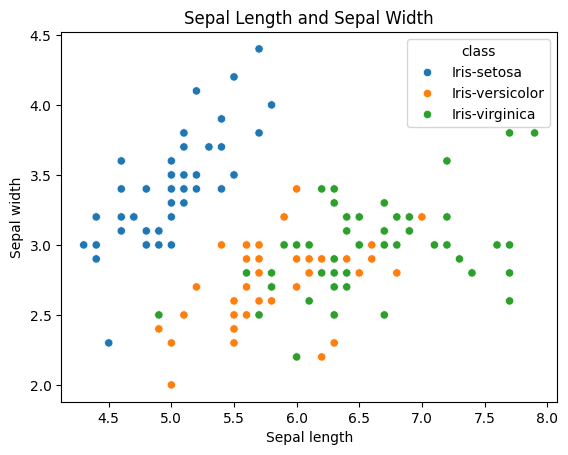

In [24]:
fig1 = sns.scatterplot(x='Sepal length' , y='Sepal width', hue='class', data=iris_data)
fig1.set(title='Sepal Length and Sepal Width')

[Text(0.5, 1.0, 'Petal Length and Petal Width')]

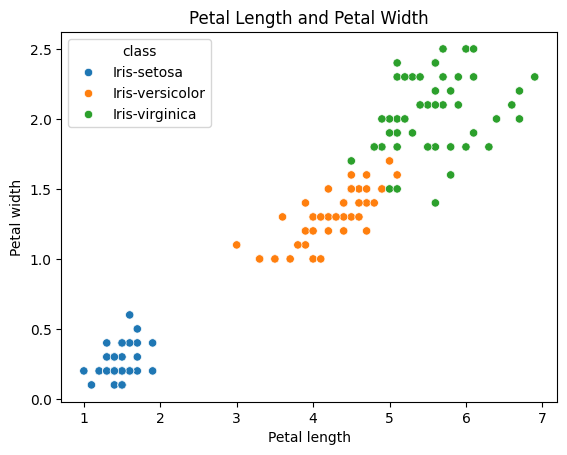

In [25]:
fig2 = sns.scatterplot(x='Petal length', y='Petal width', hue='class', data=iris_data)
fig2.set(title='Petal Length and Petal Width')

In [26]:
feat = iris_data.iloc[:, 0:4]
label = iris_data.iloc[:, 4]
print('Features: ')
print(feat)
print('Label: ')
print(label)

Features: 
     Sepal length  Sepal width  Petal length  Petal width
0             4.9          3.0           1.4          0.2
1             4.7          3.2           1.3          0.2
2             4.6          3.1           1.5          0.2
3             5.0          3.6           1.4          0.2
4             5.4          3.9           1.7          0.4
..            ...          ...           ...          ...
144           6.7          3.0           5.2          2.3
145           6.3          2.5           5.0          1.9
146           6.5          3.0           5.2          2.0
147           6.2          3.4           5.4          2.3
148           5.9          3.0           5.1          1.8

[149 rows x 4 columns]
Label: 
0         Iris-setosa
1         Iris-setosa
2         Iris-setosa
3         Iris-setosa
4         Iris-setosa
            ...      
144    Iris-virginica
145    Iris-virginica
146    Iris-virginica
147    Iris-virginica
148    Iris-virginica
Name: class, Length

In [27]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(feat, label, test_size=0.2, random_state=0)
print('Number of train data ', X_train.shape[0])
print('Number of data test ', y_test.shape[0])

Number of train data  119
Number of data test  30


In [28]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors = 5, weights = 'distance')

knn.fit(X_train, y_train)

train_acc = knn.score(X_train, y_train)

print("The accuracy of KNN classifier on training data is : {:.3f}".format(train_acc))

The accuracy of KNN classifier on training data is : 1.000


In [29]:
knn_test_acc = knn.score(X_test, y_test)

print('The accuracy of KNN classifier on test data is : {:.3f}'.format(knn_test_acc))

The accuracy of KNN classifier on test data is : 0.967


Text(0.5, 1.0, 'Confusion Matrix')

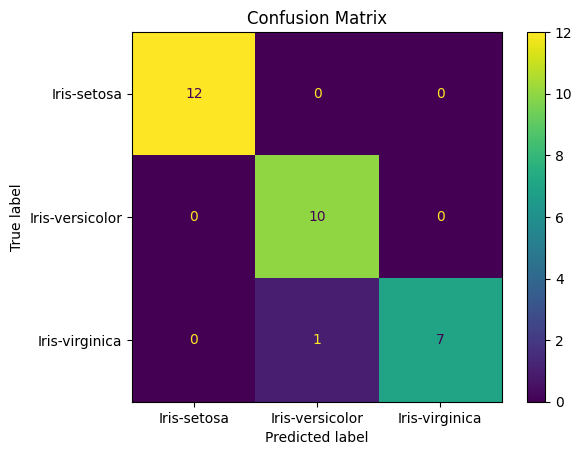

In [30]:
from sklearn.metrics import ConfusionMatrixDisplay
disp = ConfusionMatrixDisplay.from_estimator(knn, X_test, y_test)
disp.ax_.set_title('Confusion Matrix')

In [31]:
from subprocess import check_output
from sklearn import tree
from sklearn.pipeline import make_pipeline
from sklearn import preprocessing
from sklearn.model_selection import ShuffleSplit
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import GridSearchCV

In [32]:
data = pd.read_csv('iris.data')
feat = data.iloc[:, 0:4]
label = data.iloc[:, 4]

In [33]:
from sklearn.neighbors import KNeighborsClassifier

n_range = list(range(1, 10))
weight_list = ['uniform', 'dsiatnce']
param_grid = {'n_neighbors' : n_range, 'weights' : weight_list}
grid = GridSearchCV(estimator = KNeighborsClassifier(),
                    param_grid = param_grid,
                    cv = 3,
                    scoring = 'accuracy',
                    refit = True)
knn_model = make_pipeline(preprocessing.StandardScaler(), grid)
knn_model.fit(feat, label)
print('Acurracy of the tuned model: %.4f' %grid.best_score_)
print(grid.best_params_)

Acurracy of the tuned model: 0.9664
{'n_neighbors': 8, 'weights': 'uniform'}


c:\Users\keena\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\model_selection\_validation.py:528: FitFailedWarning: 
27 fits failed out of a total of 54.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
27 fits failed with the following error:
Traceback (most recent call last):
  File "c:\Users\keena\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\model_selection\_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
    ~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\keena\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\base.py", line 1382, in wrapper
    estimator._validate_params()
    ~~~~~~~~~~~~~~~~~~~~~~~~~~^^
  File "c:\Us

In [34]:
import pickle
with open('knn_model.pickle', 'wb') as f:
    pickle.dump(knn_model, f)

In [35]:
with open('knn_model.pickle', 'rb') as f:
    model = pickle.load(f)

new_data = [5.1, 3.5, 1.4, 0.2]
X = np.array([new_data])
prediction = model.predict(X)
print('Prediction of Species: {}'.format(prediction))

Prediction of Species: ['Iris-setosa']


c:\Users\keena\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
